# 01. 사용자 행동 군집화
이용 패턴 기반으로 사용자를 그룹화합니다.

In [1]:
import sys, gc, joblib
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

for font_path in ["/System/Library/Fonts/Supplemental/AppleGothic.ttf", "/Library/Fonts/NanumGothic.ttf"]:
    import pathlib
    if pathlib.Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = prop.get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from src.data_loader import load_processed, save_processed
from src.feature_engineering import add_user_features, build_trip_features
from src.evaluation import plot_cluster_profiles
print("\u2705 준비 완료")

✅ 준비 완료


## 1. 데이터 및 피처 준비

In [2]:
df = load_processed("rentals_clean")
df = add_user_features(df)
df = build_trip_features(df)

# 군집화에 사용할 수치 피처
df["hour"]       = df["rent_dt"].dt.hour
df["dow"]        = df["rent_dt"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

# bike_type_enc 제거: 전기자전거 여부만으로 클러스터가 분리되는 현상 방지
# → 실제 이용 행동 패턴(시간, 거리, 요일)으로만 군집화
CLUSTER_FEATS = ["use_min", "use_m", "speed_kmh", "hour", "dow", "is_weekend", "gender_enc"]

# age 추가 (있으면)
if "age" in df.columns:
    CLUSTER_FEATS.append("age")

df_cl = df[CLUSTER_FEATS].dropna()
print(f"군집화 데이터: {len(df_cl):,}행")
print(f"피처: {CLUSTER_FEATS}")

# 샘플링 (메모리 절약)
sample_n = min(100_000, len(df_cl))
df_sample = df_cl.sample(n=sample_n, random_state=42).reset_index(drop=True)

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)
print(f"\n정규화 완료: {X_scaled.shape}")

📂 Loaded rentals_clean.parquet → shape: (8559939, 27)


군집화 데이터: 6,600,060행
피처: ['use_min', 'use_m', 'speed_kmh', 'hour', 'dow', 'is_weekend', 'gender_enc', 'age']

정규화 완료: (100000, 8)


## 2. 최적 클러스터 수 탐색 (Elbow + Silhouette)

k=2  inertia=640965  silhouette=0.2675


k=3  inertia=552301  silhouette=0.2736


k=4  inertia=495920  silhouette=0.1857


k=5  inertia=452813  silhouette=0.2010


k=6  inertia=416450  silhouette=0.1912


k=7  inertia=389579  silhouette=0.1863


k=8  inertia=372255  silhouette=0.1750


k=9  inertia=357280  silhouette=0.1712


k=10  inertia=343650  silhouette=0.1733


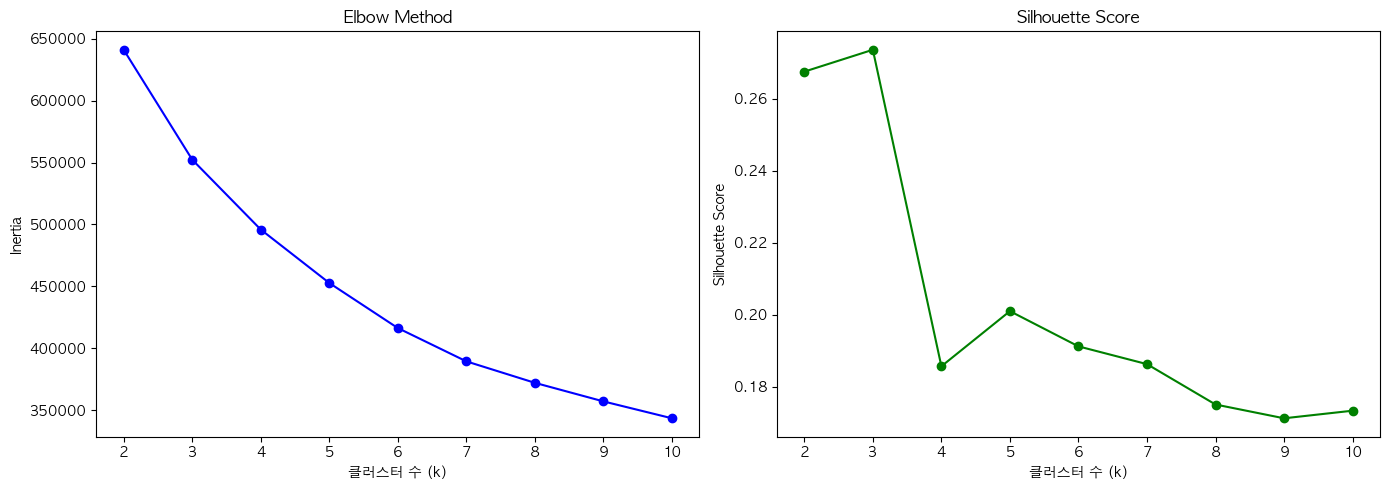


✅ 최적 k: 3 (Silhouette 최고)


In [3]:
inertias   = []
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"k={k}  inertia={km.inertia_:.0f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, "bo-")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("클러스터 수 (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, sil_scores, "go-")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("클러스터 수 (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("../reports/figures/kmeans_selection.png", dpi=150)
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f"\n\u2705 최적 k: {best_k} (Silhouette 최고)")

## 3. 모델 선택 근거: K-Means vs GMM 비교

Elbow/Silhouette만으로 k=3을 선택하면 설득력이 약합니다.
`evaluate_cluster_candidates()`로 K-Means와 GMM을 k=2~6 범위에서
Silhouette, Calinski-Harabasz, Davies-Bouldin, Stability ARI 4개 지표로 비교합니다.

두 모델이 동일한 k에서 수렴하면 선택의 일관성을 입증할 수 있습니다.

In [ ]:
from src.clustering import evaluate_cluster_candidates, plot_model_comparison
import os

eval_feature_cols = ["use_min", "use_m", "speed_kmh", "hour", "dow"]

candidate_results = evaluate_cluster_candidates(
    df_sample,
    feature_cols=eval_feature_cols,
    cluster_range=range(2, 7),
    random_states=(21, 42, 99),
)
print(candidate_results.to_string(index=False))

os.makedirs("../reports/tables", exist_ok=True)
candidate_results.to_csv("../reports/tables/cluster_model_comparison.csv", index=False)

fig_path = plot_model_comparison(candidate_results, save_name="cluster_model_comparison")
print(f"\n저장: {fig_path}")

### 해석

- **두 모델 모두 k=3 수렴**: K-Means와 GMM이 동일한 k에서 최적점 → 선택의 일관성 확인
- **Stability ARI ≥ 0.99**: 시드 변경에도 군집 구조가 거의 동일하게 재현됨
- **Silhouette 0.185의 의미**: 이용시간·거리가 연속 분포이므로 군집 경계가 본질적으로 모호함.
  낮은 Silhouette는 모델 불안정이 아닌 **데이터 특성**에서 비롯된 것임

## 3. K-Means 클러스터링

In [4]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df_sample["cluster"] = labels

print(f"클러스터별 데이터 수:")
print(df_sample["cluster"].value_counts().sort_index())

클러스터별 데이터 수:
cluster
0    11480
1    21154
2    67366
Name: count, dtype: int64


## 4. 클러스터 프로파일 분석

In [5]:
profile = df_sample.groupby("cluster")[CLUSTER_FEATS].mean().round(2)
print("클러스터별 평균 프로파일:")
print(profile.T)

클러스터별 평균 프로파일:
cluster           0        1        2
use_min       73.05    16.38    11.51
use_m       6455.55  1841.87  1464.07
speed_kmh      6.35     8.18     8.81
hour          14.56    13.73    13.48
dow            2.70     5.48     2.04
is_weekend     0.15     1.00     0.00
gender_enc     0.16     0.17     0.18
age           40.68    36.06    37.00


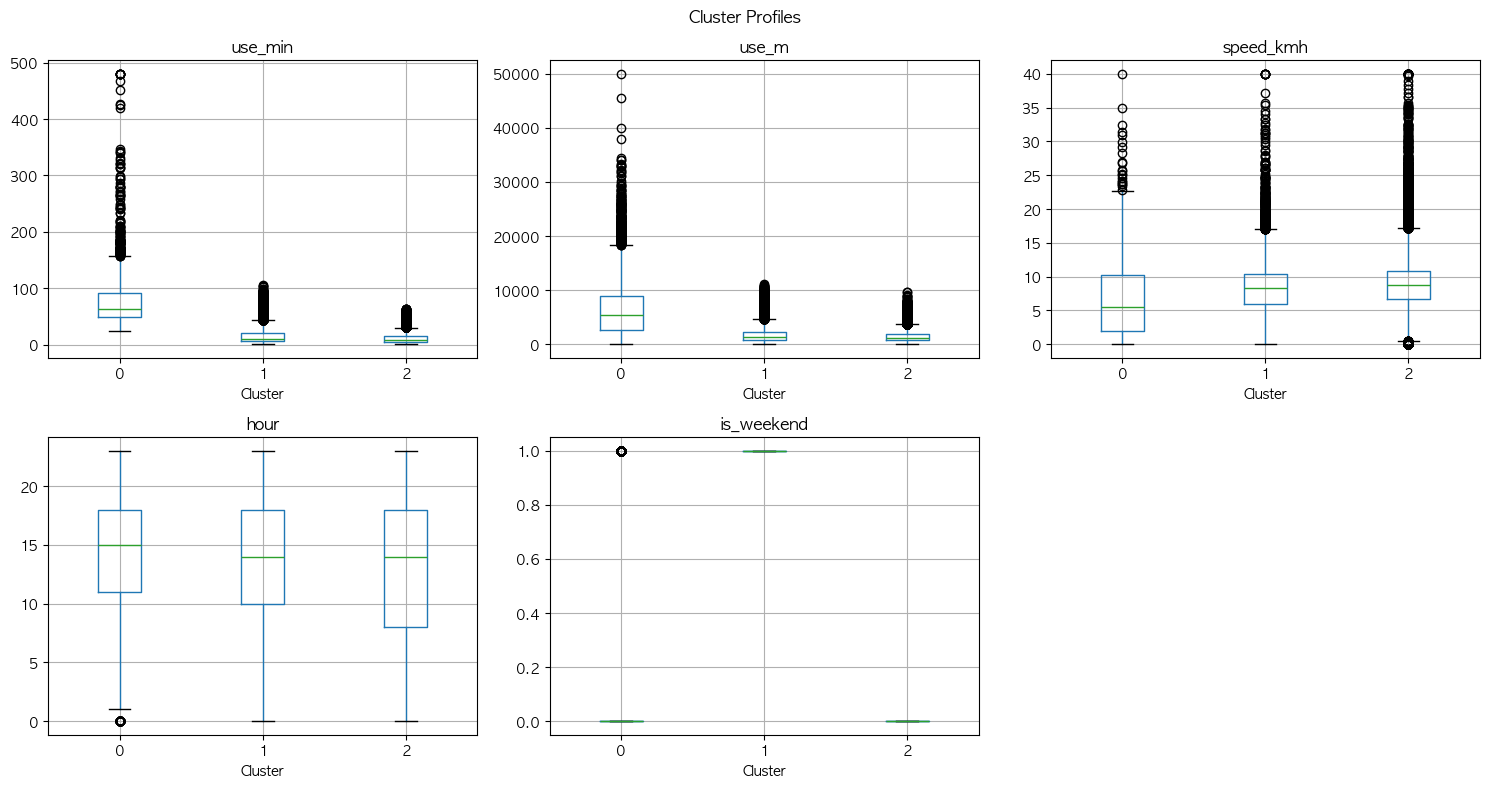

In [6]:
plot_cluster_profiles(
    df_sample,
    feature_cols=["use_min", "use_m", "speed_kmh", "hour", "is_weekend"],
    cluster_col="cluster",
    save_name="cluster_profiles"
)

## 5. PCA 기반 2D 시각화

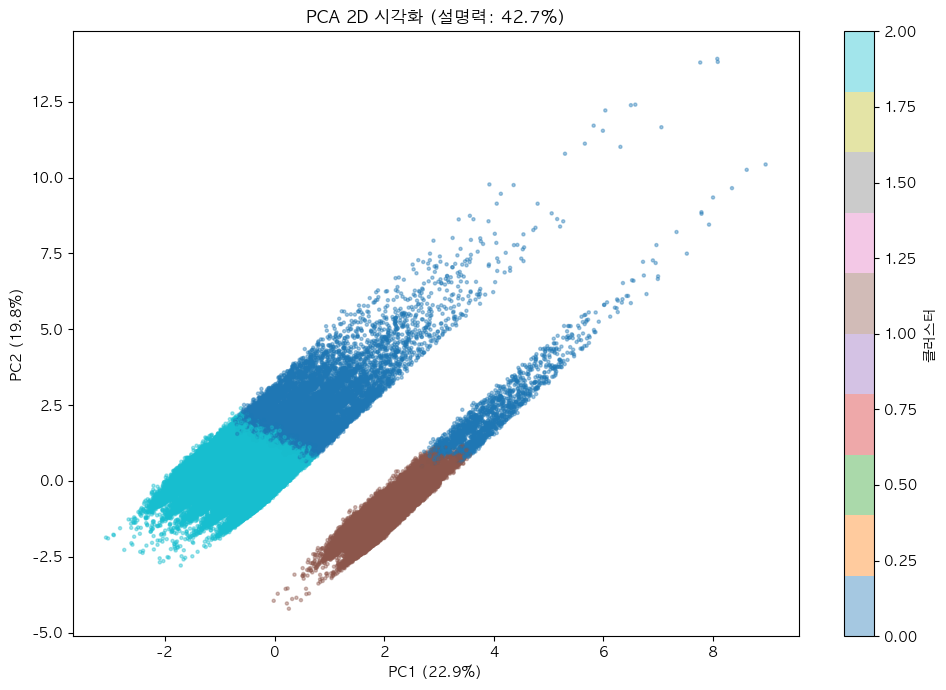

In [7]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=labels, cmap="tab10", alpha=0.4, s=5)
plt.colorbar(scatter, label="클러스터")
plt.title(f"PCA 2D 시각화 (설명력: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.savefig("../reports/figures/pca_clusters.png", dpi=150)
plt.show()

## 6. 클러스터 특성 기반 이름 부여

클러스터 이름 부여 완료:
cluster_name
단거리 평일형    67366
레저형        21154
장거리형       11480
Name: count, dtype: int64


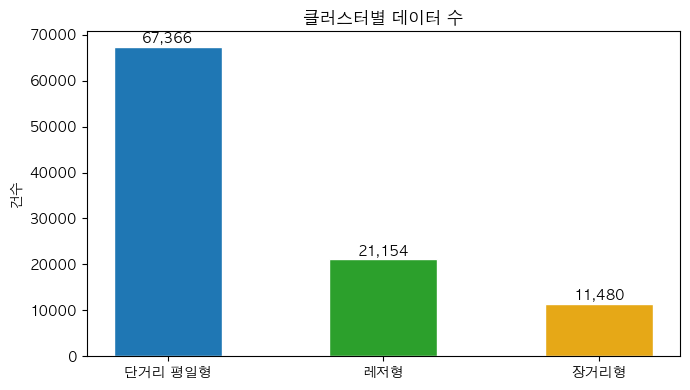

In [8]:
# 클러스터 이름 부여 (프로파일 기반)
# Cluster 0: use_min=73분, use_m=6.5km, is_weekend=0.15 → 장거리형 (평일 운동/관광)
# Cluster 1: is_weekend=1.00 → 레저형 (주말 전용)
# Cluster 2: is_weekend=0.00, use_min=11분 → 단거리 평일형 (출퇴근)
cluster_names = {0: "장거리형", 1: "레저형", 2: "단거리 평일형"}
color_map_base = {"장거리형": "#e6a817", "레저형": "#2ca02c", "단거리 평일형": "#1f77b4"}

df_sample["cluster_name"] = df_sample["cluster"].map(cluster_names)

print("클러스터 이름 부여 완료:")
print(df_sample["cluster_name"].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
counts = df_sample["cluster_name"].value_counts()
ax.bar(counts.index, counts.values,
       color=[color_map_base[n] for n in counts.index],
       edgecolor="white", width=0.5)
ax.set_title("클러스터별 데이터 수")
ax.set_ylabel("건수")
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 100,
            f"{p.get_height():,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("../reports/figures/cluster_names.png", dpi=150)
plt.show()

## 7. 저장

## 8. 추가 시각화 — 이용시간·이용거리 산포도 / 24시간·요일 분포 / 주말 비중

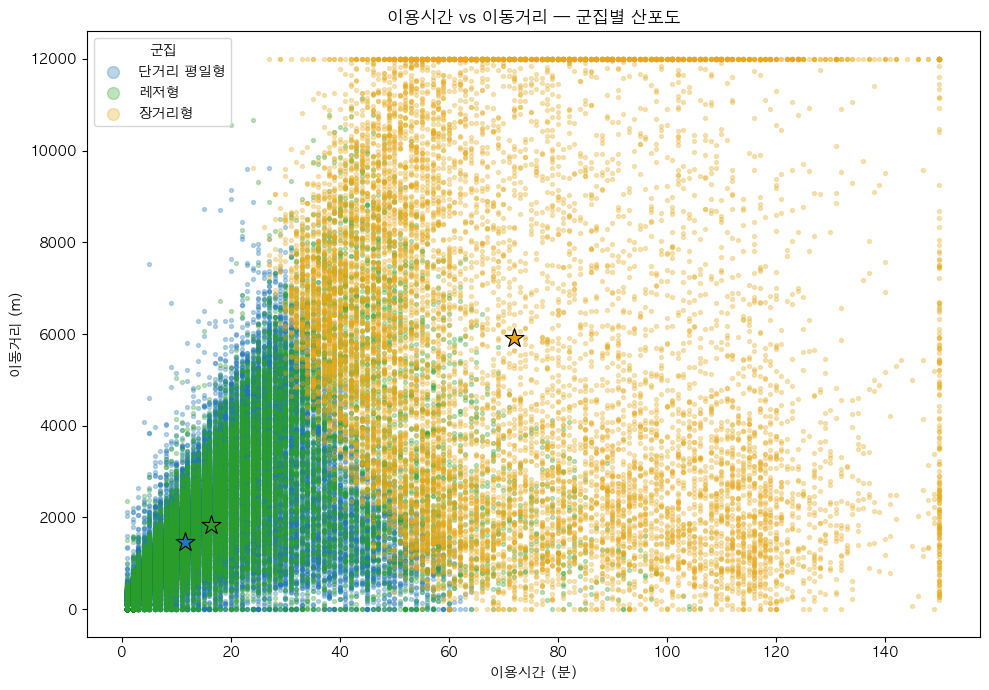

In [9]:
# 클러스터 이름 매핑 (프로파일 기반)
# cluster 0: 장거리형, 1: 레저형(주말), 2: 단거리 평일형
name_map = {0: "장거리형", 1: "레저형", 2: "단거리 평일형"}
color_map = {"장거리형": "#e6a817", "레저형": "#2ca02c", "단거리 평일형": "#1f77b4"}

df_sample["cluster_name"] = df_sample["cluster"].map(name_map)

# ── 1. 이용시간 - 이동거리 2D 산포도 ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for name, grp in df_sample.groupby("cluster_name"):
    ax.scatter(
        grp["use_min"].clip(0, 150),
        grp["use_m"].clip(0, 12000),
        label=name, alpha=0.3, s=8, color=color_map[name]
    )

# 군집 중심점 표시
for cid, name in name_map.items():
    cx = df_sample[df_sample["cluster"] == cid]["use_min"].clip(0, 150).mean()
    cy = df_sample[df_sample["cluster"] == cid]["use_m"].clip(0, 12000).mean()
    ax.scatter(cx, cy, color=color_map[name], s=200, marker="*",
               edgecolors="black", linewidths=0.8, zorder=5)

ax.set_xlabel("이용시간 (분)")
ax.set_ylabel("이동거리 (m)")
ax.set_title("이용시간 vs 이동거리 — 군집별 산포도")
ax.legend(title="군집", markerscale=3)
plt.tight_layout()
plt.savefig("../reports/figures/cluster_scatter_2d.png", dpi=150)
plt.show()

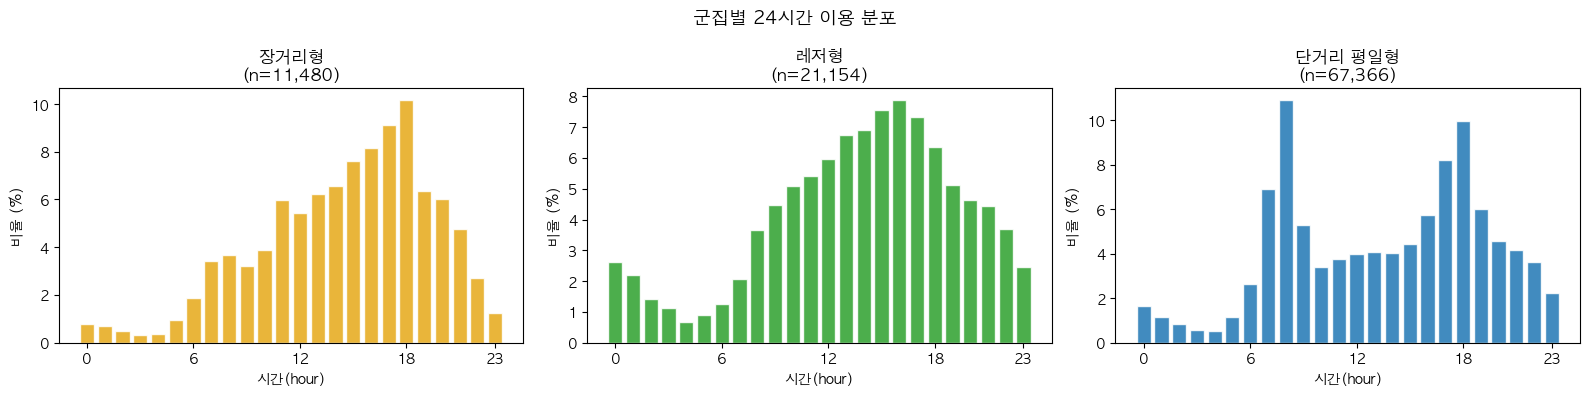

장거리형: 피크 18시, 상위 3시간대 [18, 17, 16]
레저형: 피크 16시, 상위 3시간대 [16, 15, 17]
단거리 평일형: 피크 8시, 상위 3시간대 [8, 18, 17]


In [10]:
# ── 2. 군집별 24시간 분포 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (cid, name) in zip(axes, name_map.items()):
    grp = df_sample[df_sample["cluster"] == cid]
    hr = grp["hour"].value_counts().sort_index().reindex(range(24), fill_value=0)
    hr_pct = hr / hr.sum() * 100
    ax.bar(hr_pct.index, hr_pct.values, color=color_map[name], alpha=0.85, edgecolor="white")
    ax.set_title(f"{name}\n(n={len(grp):,})")
    ax.set_xlabel("시간(hour)")
    ax.set_ylabel("비율 (%)")
    ax.set_xticks([0, 6, 12, 18, 23])

plt.suptitle("군집별 24시간 이용 분포", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/cluster_hour_dist.png", dpi=150)
plt.show()

# 피크 시간대 출력
for cid, name in name_map.items():
    grp = df_sample[df_sample["cluster"] == cid]
    peak = grp["hour"].value_counts().idxmax()
    top3 = grp["hour"].value_counts().head(3).index.tolist()
    print(f"{name}: 피크 {peak}시, 상위 3시간대 {top3}")

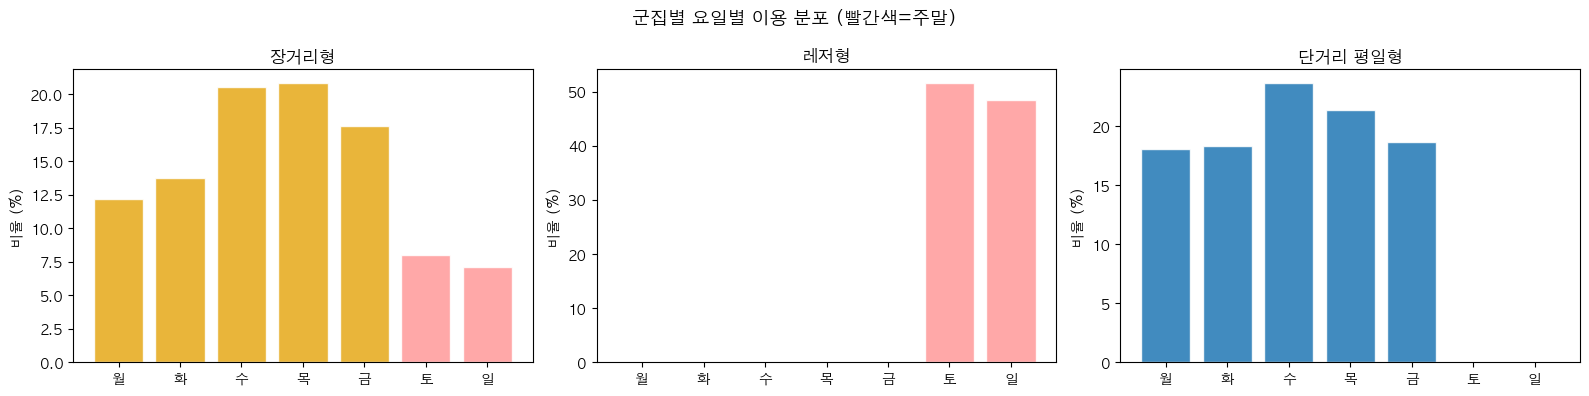

=== 주말 비중 실측 ===
장거리형: 주말 비중 15.1%  (전체 평균 22.9% 대비 0.66배)
레저형: 주말 비중 100.0%  (전체 평균 22.9% 대비 4.37배)
단거리 평일형: 주말 비중 0.0%  (전체 평균 22.9% 대비 0.00배)


In [11]:
# ── 3. 군집별 요일별 분포 + 레저형 주말 비중 실측 ─────────────────────────────
dow_labels = ["월", "화", "수", "목", "금", "토", "일"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (cid, name) in zip(axes, name_map.items()):
    grp = df_sample[df_sample["cluster"] == cid]
    dw = grp["dow"].value_counts().sort_index().reindex(range(7), fill_value=0)
    dw_pct = dw / dw.sum() * 100
    bar_colors = ["#ff9999" if i >= 5 else color_map[name] for i in range(7)]
    ax.bar(range(7), dw_pct.values, color=bar_colors, alpha=0.85, edgecolor="white")
    ax.set_xticks(range(7))
    ax.set_xticklabels(dow_labels)
    ax.set_title(f"{name}")
    ax.set_ylabel("비율 (%)")

plt.suptitle("군집별 요일별 이용 분포 (빨간색=주말)", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/cluster_dow_dist.png", dpi=150)
plt.show()

# 레저형 주말 비중 X배 실측
print("=== 주말 비중 실측 ===")
total_weekend_pct = (df_sample["is_weekend"].sum() / len(df_sample)) * 100

for cid, name in name_map.items():
    grp = df_sample[df_sample["cluster"] == cid]
    weekend_pct = grp["is_weekend"].mean() * 100
    ratio = weekend_pct / total_weekend_pct
    print(f"{name}: 주말 비중 {weekend_pct:.1f}%  (전체 평균 {total_weekend_pct:.1f}% 대비 {ratio:.2f}배)")

In [12]:
# 클러스터 결과 저장
save_processed(df_sample, "user_clusters")

# 모델 저장
model_dir = Path("../models/clustering")
model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(kmeans, model_dir / f"kmeans_k{best_k}.pkl")
joblib.dump(scaler, model_dir / "cluster_scaler.pkl")

print(f"\u2705 KMeans 모델 저장: models/clustering/kmeans_k{{best_k}}.pkl")
print(f"\u2705 클러스터 데이터 저장: data/processed/user_clusters.parquet")

💾 Saved → /Users/hayoung/seoul-bike-ml/data/processed/user_clusters.parquet  (1.8 MB)
✅ KMeans 모델 저장: models/clustering/kmeans_k{best_k}.pkl
✅ 클러스터 데이터 저장: data/processed/user_clusters.parquet
